
1. Load 25 May Pioreactor exports.
2. Build cycle-level dosing input `u(t)` by summing `add_media` events per 6-minute cycle.
3. Build 13 reservoir features from OD, AS7341 spectrum, normalized OD, and growth rate.
4. Plot raw waveforms.
5. Train a no-delay ridge readout.
6. Add delay embedding and sweep delay depths.
7. Run verification controls to check that the delay=3 result depends on real alignment, not coding leakage.

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler

# Direct data folder for this run.
DATA_PATH = Path(r"D:\omnibio\results\25th may")
OUT_DIR = Path("results/outputs/mg_25may")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CYCLE_MIN = 6
ALPHAS = np.logspace(-4, 4, 50)
MAX_DELAY = 10
RANDOM_SEED = 42


### Methods

In [28]:
def cycle_mean(df: pd.DataFrame, value_col: str, t0: pd.Timestamp, total_cycles: int) -> pd.Series:
    tmp = df.copy()
    tmp["t_min"] = (tmp["timestamp"] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp["t_min"] >= 0) & (tmp["t_min"] < total_cycles * CYCLE_MIN)]
    tmp["cycle"] = np.floor(tmp["t_min"] / CYCLE_MIN).astype(int)
    return (
        tmp.groupby("cycle")[value_col]
        .mean()
        .reindex(range(total_cycles))
        .interpolate(limit_direction="both")
    )


def ridge_loo(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)

    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())

    nmse = mean_squared_error(y, yp) / np.var(y)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)

    model.fit(Xs, y)
    return yp, nmse, mae, r2, model, scaler, rcv.alpha_


def ridge_cv_predict(X: np.ndarray, y: np.ndarray, cv):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)

    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=cv)

    nmse = mean_squared_error(y, yp) / np.var(y)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    return yp, nmse, mae, r2, rcv.alpha_


def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0:
        return X.copy(), y.copy()

    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]


def chronological_block_metrics(X: np.ndarray, y: np.ndarray):
    splits = [
        ("first_70_train_last_30_test", 0.70),
        ("first_60_train_last_40_test", 0.60),
    ]
    rows = []
    for label, frac in splits:
        split = int(np.floor(len(y) * frac))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        rcv = RidgeCV(alphas=ALPHAS, cv=None)
        rcv.fit(X_train_sc, y_train)
        model = Ridge(alpha=rcv.alpha_)
        model.fit(X_train_sc, y_train)
        pred = model.predict(X_test_sc)

        rows.append(
            {
                "test": label,
                "train_samples": len(y_train),
                "test_samples": len(y_test),
                "alpha": rcv.alpha_,
                "nmse": mean_squared_error(y_test, pred) / np.var(y_test),
                "r2": r2_score(y_test, pred),
                "mae_ml": mean_absolute_error(y_test, pred),
            }
        )
    return pd.DataFrame(rows)

## Load data

In [29]:
spec = pd.read_csv(
    DATA_PATH / "as7341_spectrum_readings-Demo_experiment-all_units-20260526090312.csv",
    parse_dates=["timestamp"],
)
dosing = pd.read_csv(
    DATA_PATH / "dosing_events-Demo_experiment-all_units-20260526090312.csv",
    parse_dates=["timestamp"],
)
growth = pd.read_csv(
    DATA_PATH / "growth_rates-Demo_experiment-all_units-20260526090312.csv",
    parse_dates=["timestamp"],
)
od_filt = pd.read_csv(
    DATA_PATH / "od_readings_filtered-Demo_experiment-all_units-20260526090312.csv",
    parse_dates=["timestamp"],
)
od = pd.read_csv(
    DATA_PATH / "od_readings-Demo_experiment-all_units-20260526090312.csv",
    parse_dates=["timestamp"],
)
settings = pd.read_csv(
    DATA_PATH / "dosing_automation_settings-Demo_experiment-all_units-20260526090312.csv",
    parse_dates=["started_at"],
)

settings[["started_at", "automation_name", "json_settings", "started_at_localtime"]]


,started_at,automation_name,json_settings,started_at_localtime
0,2026-05-25 14:19:03.547000+00:00,mg_narma_dosing,"{""state"":""init"",""duration"":0.2}",2026-05-25 20:04:03.547
1,2026-05-25 15:22:20.854000+00:00,mg_narma_dosing,"{""state"":""init"",""duration"":5.0}",2026-05-25 21:07:20.854
2,2026-05-25 16:49:34.314000+00:00,mg_narma_dosing,"{""state"":""init"",""duration"":6.0}",2026-05-25 22:34:34.314


## Select the Main 6-Minute Mackey-Glass Run

The export contains short test runs and the later 6-minute run. We select the latest `mg_narma_dosing` automation with `duration=6.0`.

Important: a single requested media volume can appear as multiple `add_media` rows because Pioreactor may split pump actions. Therefore the true input signal `u(t)` is the **sum of add_media volumes inside each 6-minute cycle**.

In [30]:
settings_6min = settings[
    (settings["automation_name"] == "mg_narma_dosing")
    & settings["json_settings"].str.contains('"duration":6.0', regex=False, na=False)
]
if settings_6min.empty:
    raise RuntimeError("Could not find the 6-minute mg_narma_dosing run in settings.")

run_start = settings_6min["started_at"].max()

media = dosing[
    (dosing["source_of_event"] == "dosing_automation:mg_narma_dosing")
    & (dosing["event"] == "add_media")
    & (dosing["timestamp"] >= run_start)
].sort_values("timestamp").copy()

media["t_min"] = (media["timestamp"] - run_start).dt.total_seconds() / 60.0
media["cycle"] = np.floor(media["t_min"] / CYCLE_MIN).astype(int)

u = media.groupby("cycle")["volume_change_ml"].sum()
total_cycles = int(u.index.max()) + 1
u = u.reindex(range(total_cycles), fill_value=0.0)
time_min = np.arange(total_cycles) * CYCLE_MIN

print("Run start UTC:", run_start)
print(f"Cycles: {total_cycles}, exported duration: {total_cycles * CYCLE_MIN} min")
print(f"Dose min/max/mean/sum: {u.min():.4f} / {u.max():.4f} / {u.mean():.4f} / {u.sum():.4f} mL")

pd.DataFrame({"cycle": u.index, "time_min": time_min, "dose_ml": u.values}).head(30)

Run start UTC: 2026-05-25 16:49:34.314000+00:00
Cycles: 68, exported duration: 408 min
Dose min/max/mean/sum: 0.0500 / 0.4000 / 0.2743 / 18.6511 mL


,cycle,time_min,dose_ml
0,0,0,0.059610
1,1,6,0.050613
2,2,12,0.050000
3,3,18,0.060590
4,4,24,0.084600
5,5,30,0.121692
6,6,36,0.167839
7,7,42,0.216868
8,8,48,0.263291
9,9,54,0.303768


## Resrvoir state matrix


1. `OD_45`
2. `OD_90`
3. `OD_135`
4. `nm_415`
5. `nm_445`
6. `nm_480`
7. `nm_515`
8. `nm_555`
9. `nm_590`
10. `nm_630`
11. `nm_680`
12. `growth_rate`
13. `norm_od`

In [31]:
od_45 = cycle_mean(od[od["angle"] == 45], "od_reading", run_start, total_cycles)
od_90 = cycle_mean(od[od["angle"] == 90], "od_reading", run_start, total_cycles)
od_135 = cycle_mean(od[od["angle"] == 135], "od_reading", run_start, total_cycles)

spec_series = {}
for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    spec_series[f"nm_{band}"] = cycle_mean(
        spec[spec["band"] == band], "reading", run_start, total_cycles
    )

norm_od = cycle_mean(od_filt, "normalized_od_reading", run_start, total_cycles)
growth_rate = cycle_mean(growth, "rate", run_start, total_cycles)

features = {
    "OD_45": od_45,
    "OD_90": od_90,
    "OD_135": od_135,
    **spec_series,
    "growth_rate": growth_rate,
    "norm_od": norm_od,
}
sensor_names = list(features)
X = np.column_stack([features[name].to_numpy() for name in sensor_names])
y = u.to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print(sensor_names)

X shape: (68, 13)
y shape: (68,)
['OD_45', 'OD_90', 'OD_135', 'nm_415', 'nm_445', 'nm_480', 'nm_515', 'nm_555', 'nm_590', 'nm_630', 'nm_680', 'growth_rate', 'norm_od']


## Raw Waveforms

First inspect whether the encoded Mackey-Glass input and the raw reservoir outputs have visible structure.

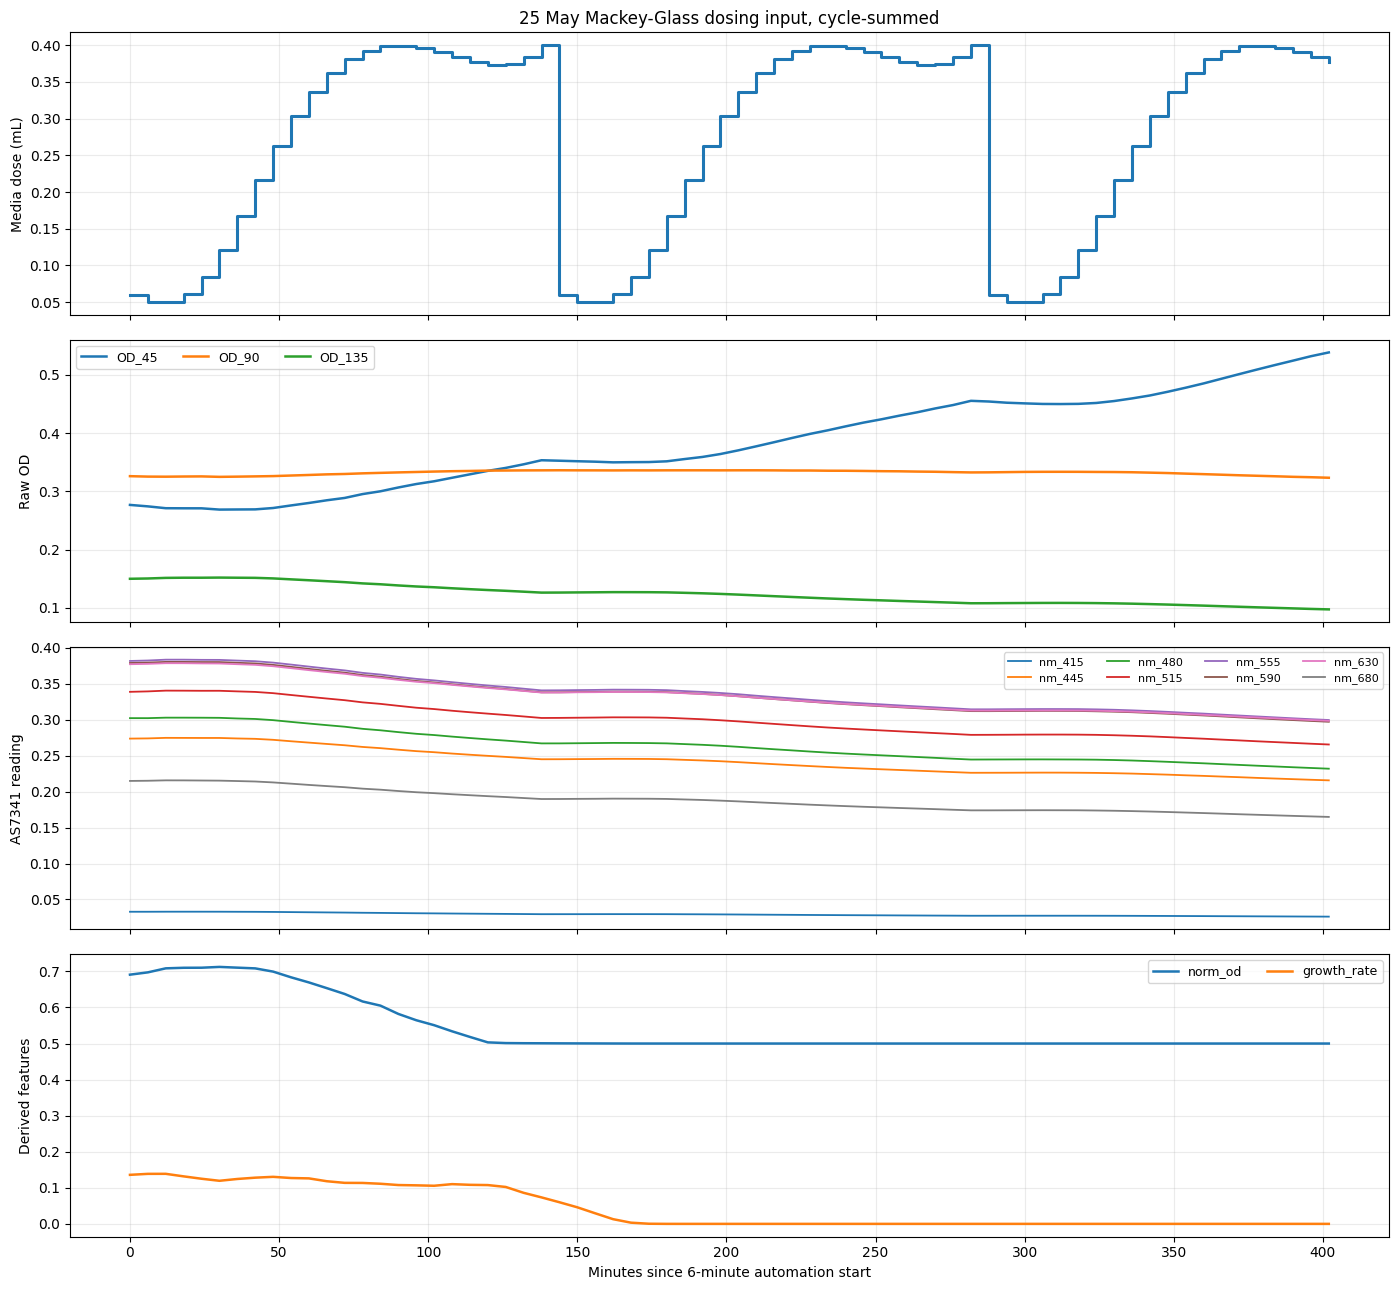

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

axes[0].step(time_min, y, where="post", color="#1f77b4", linewidth=2.2)
axes[0].set_ylabel("Media dose (mL)")
axes[0].set_title("25 May Mackey-Glass dosing input, cycle-summed")
axes[0].grid(alpha=0.25)

axes[1].plot(time_min, od_45, label="OD_45", linewidth=1.8)
axes[1].plot(time_min, od_90, label="OD_90", linewidth=1.8)
axes[1].plot(time_min, od_135, label="OD_135", linewidth=1.8)
axes[1].set_ylabel("Raw OD")
axes[1].legend(ncol=3, fontsize=9)
axes[1].grid(alpha=0.25)

for name, series in spec_series.items():
    axes[2].plot(time_min, series, label=name, linewidth=1.3)
axes[2].set_ylabel("AS7341 reading")
axes[2].legend(ncol=4, fontsize=8)
axes[2].grid(alpha=0.25)

axes[3].plot(time_min, norm_od, label="norm_od", linewidth=1.8)
axes[3].plot(time_min, growth_rate, label="growth_rate", linewidth=1.8)
axes[3].set_xlabel("Minutes since 6-minute automation start")
axes[3].set_ylabel("Derived features")
axes[3].legend(ncol=2, fontsize=9)
axes[3].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_DIR / "raw_waveforms.png", dpi=160)
plt.show()

In [ ]:
Xz = StandardScaler().fit_transform(X)
yz = (y - y.mean()) / y.std()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(time_min, yz, color="black", linewidth=2.6, label="dosing volume z-score")
for i, name in enumerate(sensor_names):
    ax.plot(time_min, Xz[:, i], linewidth=1.0, alpha=0.65, label=name)
ax.set_title("Normalized raw waveforms: input vs all 13 reservoir features")
ax.set_xlabel("Minutes since 6-minute automation start")
ax.set_ylabel("z-score")
ax.grid(alpha=0.25)
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "normalized_overlay_all13.png", dpi=160)
plt.show()

## Initial Readout: All 13 Features

To test whether the current reservoir state alone can reconstruct the current dosing volume.

No-delay all-13 readout: alpha=0.0001, NMSE=0.6806, R2=0.3194, MAE=0.0875 mL


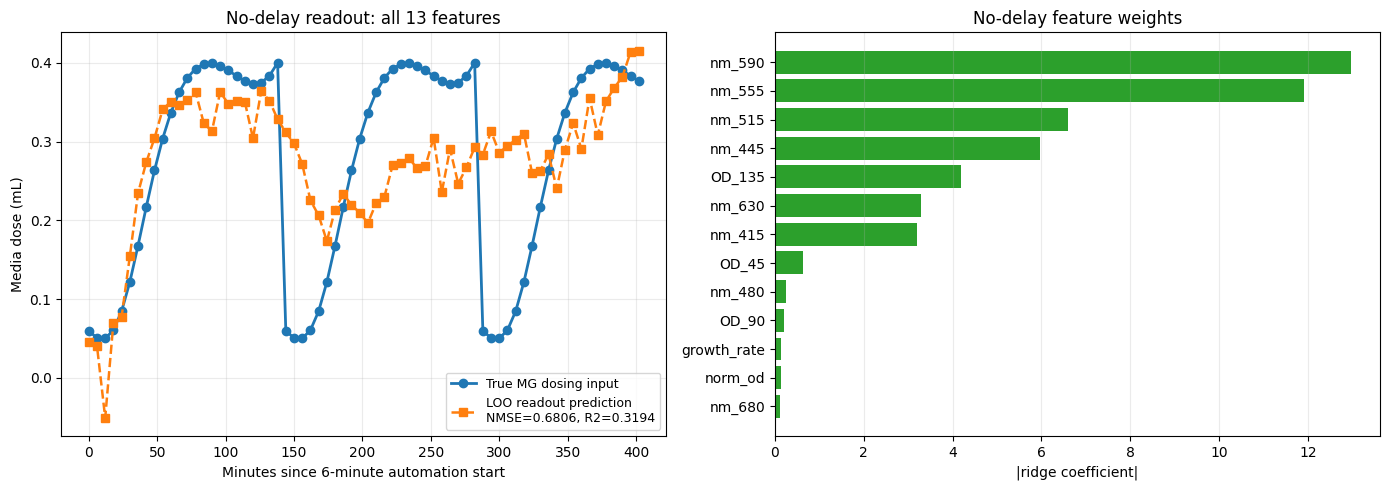

,feature,abs_coef
0,nm_590,12.977648
1,nm_555,11.919828
2,nm_515,6.590027
3,nm_445,5.961720
4,OD_135,4.183047
5,nm_630,3.282236
6,nm_415,3.203058
7,OD_45,0.622432
8,nm_480,0.239388
9,OD_90,0.202105


In [33]:
y_pred, nmse, mae, r2, model, scaler, alpha = ridge_loo(X, y)

print(f"No-delay all-13 readout: alpha={alpha}, NMSE={nmse:.4f}, R2={r2:.4f}, MAE={mae:.4f} mL")

importances = np.abs(model.coef_)
rank = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(time_min, y, "o-", linewidth=2.0, label="True MG dosing input")
axes[0].plot(
    time_min,
    y_pred,
    "s--",
    linewidth=1.8,
    label=f"LOO readout prediction\nNMSE={nmse:.4f}, R2={r2:.4f}",
)
axes[0].set_xlabel("Minutes since 6-minute automation start")
axes[0].set_ylabel("Media dose (mL)")
axes[0].set_title("No-delay readout: all 13 features")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

axes[1].barh([sensor_names[i] for i in rank], importances[rank], color="#2ca02c")
axes[1].invert_yaxis()
axes[1].set_xlabel("|ridge coefficient|")
axes[1].set_title("No-delay feature weights")
axes[1].grid(alpha=0.25, axis="x")

fig.tight_layout()
fig.savefig(OUT_DIR / "no_delay_readout_all13.png", dpi=160)
plt.show()

pd.DataFrame({"feature": [sensor_names[i] for i in rank], "abs_coef": importances[rank]})

## Delay Embedding Sweep

Now we test whether short-term memory improves the readout. For delay `d`, each row becomes:

`[x(t), x(t-1), ..., x(t-d)]`

With 6-minute cycles, `delay=3` means current state plus the previous 18 minutes of sensor-state history.

 delay  n_samples  n_features    alpha     nmse       r2   mae_ml
     0         68          13 0.000100 0.680568 0.319432 0.087453
     1         67          26 0.000655 0.043802 0.956198 0.022317
     2         66          39 0.000212 0.038189 0.961811 0.019382
     3         65          52 0.000100 0.035875 0.964125 0.016797
     4         64          65 0.000212 0.049413 0.950587 0.019603
     5         63          78 0.000212 0.066201 0.933799 0.022547
     6         62          91 0.009103 0.076581 0.923419 0.023828
     7         61         104 0.013257 0.074141 0.925859 0.022095
     8         60         117 0.013257 0.065204 0.934796 0.020792
     9         59         130 0.013257 0.072506 0.927494 0.022707
    10         58         143 0.028118 0.084715 0.915285 0.022613

Best delayed all-13 readout: d=3, n=65, features=52, NMSE=0.0359, R2=0.9641, MAE=0.0168 mL


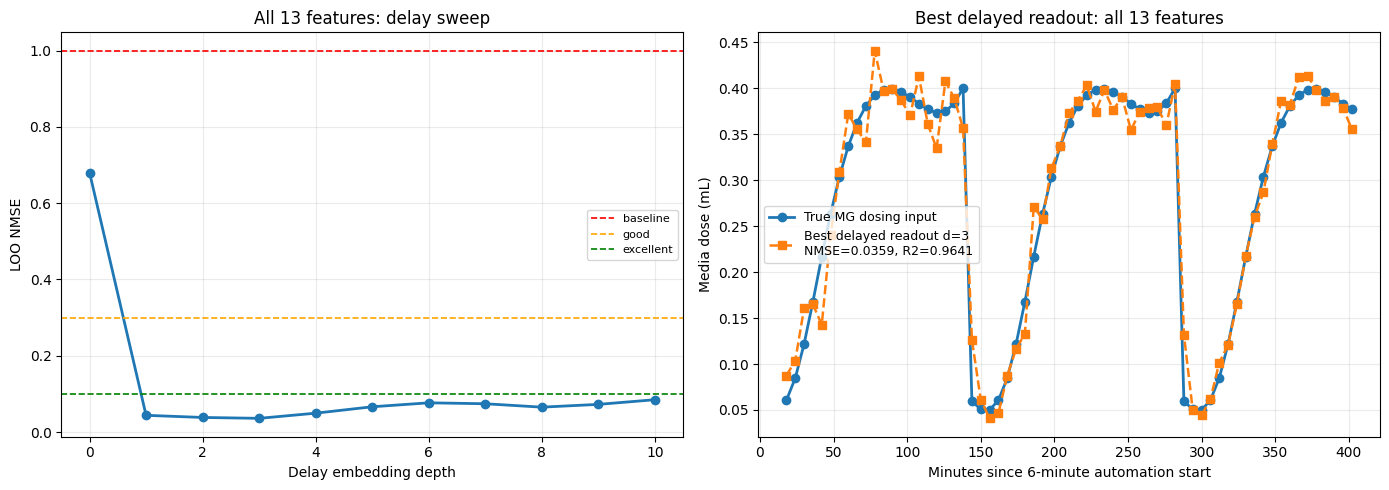

In [34]:
delay_results = []
delay_predictions = {}

for delay in range(MAX_DELAY + 1):
    Xd, yd = delay_embed(X, y, delay)
    if len(yd) < 10:
        break
    ypd, nmsed, maed, r2d, modeld, scalerd, alphad = ridge_loo(Xd, yd)
    delay_results.append(
        {
            "delay": delay,
            "n_samples": len(yd),
            "n_features": Xd.shape[1],
            "alpha": alphad,
            "nmse": nmsed,
            "r2": r2d,
            "mae_ml": maed,
        }
    )
    delay_predictions[delay] = (yd, ypd)

delay_df = pd.DataFrame(delay_results)
delay_df.to_csv(OUT_DIR / "delay_sweep_all13.csv", index=False)

best_delay_row = delay_df.loc[delay_df["nmse"].idxmin()]
best_delay = int(best_delay_row["delay"])
best_y, best_yp = delay_predictions[best_delay]
best_time_min = np.arange(best_delay, best_delay + len(best_y)) * CYCLE_MIN

print(delay_df.to_string(index=False))
print(
    f"\nBest delayed all-13 readout: d={best_delay}, "
    f"n={int(best_delay_row['n_samples'])}, "
    f"features={int(best_delay_row['n_features'])}, "
    f"NMSE={best_delay_row['nmse']:.4f}, "
    f"R2={best_delay_row['r2']:.4f}, "
    f"MAE={best_delay_row['mae_ml']:.4f} mL"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(delay_df["delay"], delay_df["nmse"], "o-", linewidth=2.0)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="baseline")
axes[0].axhline(0.3, color="orange", linestyle="--", linewidth=1.2, label="good")
axes[0].axhline(0.1, color="green", linestyle="--", linewidth=1.2, label="excellent")
axes[0].set_xlabel("Delay embedding depth")
axes[0].set_ylabel("LOO NMSE")
axes[0].set_title("All 13 features: delay sweep")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(best_time_min, best_y, "o-", linewidth=2.0, label="True MG dosing input")
axes[1].plot(
    best_time_min,
    best_yp,
    "s--",
    linewidth=1.8,
    label=(
        f"Best delayed readout d={best_delay}\n"
        f"NMSE={best_delay_row['nmse']:.4f}, R2={best_delay_row['r2']:.4f}"
    ),
)
axes[1].set_xlabel("Minutes since 6-minute automation start")
axes[1].set_ylabel("Media dose (mL)")
axes[1].set_title("Best delayed readout: all 13 features")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_DIR / "delay_sweep_all13.png", dpi=160)
plt.show()

## Verification Controls

These controls test whether the good delayed result depends on the real alignment between sensor history and dosing input.

Checks included:

1. **Aligned LOO-CV**: original result on real aligned `X` and `y`.
2. **Chronological K-fold CV**: train/test splits preserve time order within folds instead of random shuffling.
3. **Chronological holdouts**: train on early run, test on later run.
4. **Rolled target control**: same sensor matrix, but target shifted by half a motif. This breaks phase alignment.
5. **Permutation null**: shuffle target many times and rerun the readout. If the real NMSE is far below shuffled NMSE, the result is unlikely to be coding artifact.

`N_PERMUTATIONS` is set to 50 for notebook speed. Increase to 200 or 1000 for a final stronger null estimate.

In [ ]:
N_PERMUTATIONS = 50

best_X, best_y_for_tests = delay_embed(X, y, best_delay)

# 1. Chronological K-fold CV.
kfold = KFold(n_splits=5, shuffle=False)
kfold_pred, kfold_nmse, kfold_mae, kfold_r2, kfold_alpha = ridge_cv_predict(
    best_X, best_y_for_tests, kfold
)

# 2. Chronological holdout tests.
block_df = chronological_block_metrics(best_X, best_y_for_tests)
block_df.to_csv(OUT_DIR / "delay3_chronological_holdout.csv", index=False)

# 3. Deliberately invalid alignment: roll target by half a 24-cycle motif.
y_rolled = np.roll(best_y_for_tests, 12)
_, rolled_nmse, rolled_mae, rolled_r2, rolled_alpha = ridge_cv_predict(
    best_X, y_rolled, LeaveOneOut()
)

# 4. Permutation null: destroy target alignment completely.
rng = np.random.default_rng(RANDOM_SEED)
permutation_rows = []
for i in range(N_PERMUTATIONS):
    y_perm = rng.permutation(best_y_for_tests)
    _, perm_nmse, perm_mae, perm_r2, perm_alpha = ridge_cv_predict(best_X, y_perm, LeaveOneOut())
    permutation_rows.append(
        {
            "permutation": i,
            "alpha": perm_alpha,
            "nmse": perm_nmse,
            "r2": perm_r2,
            "mae_ml": perm_mae,
        }
    )

permutation_df = pd.DataFrame(permutation_rows)
permutation_df.to_csv(OUT_DIR / "delay3_permutation_null.csv", index=False)
permutation_p = (1 + (permutation_df["nmse"] <= best_delay_row["nmse"]).sum()) / (
    len(permutation_df) + 1
)

print("Delay=3 verification controls")
print(f"Aligned LOO-CV: NMSE={best_delay_row['nmse']:.4f}, R2={best_delay_row['r2']:.4f}, MAE={best_delay_row['mae_ml']:.4f} mL")
print(f"5-fold chronological CV: alpha={kfold_alpha}, NMSE={kfold_nmse:.4f}, R2={kfold_r2:.4f}, MAE={kfold_mae:.4f} mL")
print(f"Target rolled by 12 cycles: alpha={rolled_alpha}, NMSE={rolled_nmse:.4f}, R2={rolled_r2:.4f}, MAE={rolled_mae:.4f} mL")
print(f"{N_PERMUTATIONS}x shuffled-target null: median NMSE={permutation_df['nmse'].median():.4f}, min NMSE={permutation_df['nmse'].min():.4f}, p?{permutation_p:.4f}")

print("\nChronological holdout tests:")
display(block_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(permutation_df["nmse"], bins=20, color="#999999", edgecolor="white")
axes[0].axvline(best_delay_row["nmse"], color="#d62728", linewidth=2.5, label="real aligned target")
axes[0].set_xlabel("LOO NMSE after target shuffle")
axes[0].set_ylabel("count")
axes[0].set_title(f"Permutation null for delay={best_delay} readout")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

bars = axes[1].bar(
    ["LOO aligned", "5-fold time blocks", "target rolled", "shuffle median"],
    [
        best_delay_row["nmse"],
        kfold_nmse,
        rolled_nmse,
        permutation_df["nmse"].median(),
    ],
    color=["#2ca02c", "#1f77b4", "#ff7f0e", "#999999"],
)
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="baseline")
axes[1].set_ylabel("NMSE")
axes[1].set_title("Aligned readout vs controls")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(alpha=0.2, axis="y")
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(OUT_DIR / "delay3_verification_controls.png", dpi=160)
plt.show()

In [ ]:

from sklearn.model_selection import KFold

delay = 3
Xd, yd = delay_embed(X, y, delay)

# KFold with shuffle=False keeps contiguous time blocks.
cv = KFold(n_splits=5, shuffle=False)

yp, nmse, mae, r2, alpha = ridge_cv_predict(Xd, yd, cv)

t_axis = np.arange(delay, delay + len(yd)) * CYCLE_MIN

print(f"Chronological 5-fold CV: all 13 features + delay={delay}")
print(f"alpha = {alpha}")
print(f"NMSE  = {nmse:.4f}")
print(f"R²    = {r2:.4f}")
print(f"MAE   = {mae:.4f} mL")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    t_axis,
    yd,
    "o-",
    linewidth=2.2,
    markersize=5,
    label="True Mackey-Glass dosing input",
)

ax.plot(
    t_axis,
    yp,
    "s--",
    linewidth=1.8,
    markersize=5,
    label=f"Chronological 5-fold prediction\nNMSE={nmse:.4f}, R²={r2:.4f}, MAE={mae:.4f} mL",
)

ax.set_title("Chronological CV Verification: Delay=3 Readout")
ax.set_xlabel("Minutes since automation start")
ax.set_ylabel("Media dose volume (mL)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


### Save Aligned Table and Summary

This cell saves the cycle-aligned features plus the no-delay prediction and writes a compact JSON summary for later reporting.

In [ ]:
cycle_table = pd.DataFrame({"cycle": np.arange(total_cycles), "time_min": time_min, "dose_ml": y})
for name in sensor_names:
    cycle_table[name] = features[name].to_numpy()
cycle_table["pred_no_delay_all13"] = y_pred
cycle_table.to_csv(OUT_DIR / "cycle_aligned_features_and_readout.csv", index=False)

summary = {
    "run_start_utc": str(run_start),
    "cycle_min": CYCLE_MIN,
    "cycles": total_cycles,
    "duration_min_exported": float(time_min[-1] + CYCLE_MIN),
    "dose_min_ml": float(y.min()),
    "dose_max_ml": float(y.max()),
    "dose_mean_ml": float(y.mean()),
    "dose_total_ml": float(y.sum()),
    "no_delay_all13_alpha": float(alpha),
    "no_delay_all13_nmse": float(nmse),
    "no_delay_all13_r2": float(r2),
    "no_delay_all13_mae_ml": float(mae),
    "best_delay_all13": int(best_delay_row["delay"]),
    "best_delay_all13_samples": int(best_delay_row["n_samples"]),
    "best_delay_all13_features": int(best_delay_row["n_features"]),
    "best_delay_all13_alpha": float(best_delay_row["alpha"]),
    "best_delay_all13_nmse": float(best_delay_row["nmse"]),
    "best_delay_all13_r2": float(best_delay_row["r2"]),
    "best_delay_all13_mae_ml": float(best_delay_row["mae_ml"]),
    "feature_ranking_no_delay": [
        {"feature": sensor_names[i], "abs_coef": float(importances[i])} for i in rank
    ],
}

# Add verification metrics if the verification cell has already been run.
if "permutation_df" in globals():
    summary.update(
        {
            "verification_permutations": int(N_PERMUTATIONS),
            "delay3_kfold_timeblock_alpha": float(kfold_alpha),
            "delay3_kfold_timeblock_nmse": float(kfold_nmse),
            "delay3_kfold_timeblock_r2": float(kfold_r2),
            "delay3_kfold_timeblock_mae_ml": float(kfold_mae),
            "delay3_permutation_null_median_nmse": float(permutation_df["nmse"].median()),
            "delay3_permutation_null_min_nmse": float(permutation_df["nmse"].min()),
            "delay3_permutation_p_value": float(permutation_p),
            "delay3_target_rolled_alpha": float(rolled_alpha),
            "delay3_target_rolled_nmse": float(rolled_nmse),
            "delay3_target_rolled_r2": float(rolled_r2),
            "delay3_target_rolled_mae_ml": float(rolled_mae),
        }
    )

pd.Series(summary).to_json(OUT_DIR / "summary.json", indent=2)
summary

## Extended Feature Selection and Delay Sweep

This mirrors the `Reservoir Computing extended` workflow from the sine-wave notebook.

The goal is to find whether a smaller feature subset can reconstruct the Mackey-Glass input as well as, or better than, all 13 features.

Steps:
1. Rank original sensors using the all-feature delay=3 ridge readout.
2. Sweep top-N feature sets across delay values.
3. Pick the best compact model by LOO-CV NMSE.

In [ ]:
# Step 1: rank original sensors using the all-13, delay=3 model.
# Coefficients are aggregated across lags so each original sensor gets one score.

RANKING_DELAY = 3
Xd_rank, yd_rank = delay_embed(X, y, RANKING_DELAY)
yp_rank, nmse_rank, mae_rank, r2_rank, model_rank, scaler_rank, alpha_rank = ridge_loo(Xd_rank, yd_rank)

embedded_names = []
for lag in range(RANKING_DELAY + 1):
    suffix = "_t" if lag == 0 else f"_t-{lag}"
    embedded_names.extend([f"{name}{suffix}" for name in sensor_names])

coef_abs = np.abs(model_rank.coef_)
feature_scores = {name: 0.0 for name in sensor_names}

for name, score in zip(embedded_names, coef_abs):
    for sensor in sensor_names:
        if name == f"{sensor}_t" or name.startswith(f"{sensor}_t-"):
            feature_scores[sensor] += float(score)
            break

ranked_features = sorted(feature_scores.items(), key=lambda item: item[1], reverse=True)
ranked_feature_names = [name for name, score in ranked_features]

feature_rank_df = pd.DataFrame(ranked_features, columns=["feature", "lag_aggregated_abs_coef"])
feature_rank_df.to_csv(OUT_DIR / "feature_ranking_delay3.csv", index=False)

print(f"All-13 delay={RANKING_DELAY} ranking model: NMSE={nmse_rank:.4f}, R2={r2_rank:.4f}, MAE={mae_rank:.4f} mL")
display(feature_rank_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feature_rank_df["feature"], feature_rank_df["lag_aggregated_abs_coef"], color="#2ca02c")
ax.invert_yaxis()
ax.set_xlabel("Sum |ridge coefficient| across delay lags")
ax.set_title("Feature ranking from all-13 delay=3 readout")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: sweep top-N ranked features across delay embeddings.

TOP_N_LIST = list(range(1, len(sensor_names) + 1))
DELAY_LIST = list(range(0, 11))

subset_results = []

for n_features in TOP_N_LIST:
    selected_names = ranked_feature_names[:n_features]
    selected_idx = [sensor_names.index(name) for name in selected_names]
    X_sub = X[:, selected_idx]

    for delay in DELAY_LIST:
        Xd, yd = delay_embed(X_sub, y, delay)
        if len(yd) < 10:
            continue

        yp, nmse_sub, mae_sub, r2_sub, model_sub, scaler_sub, alpha_sub = ridge_loo(Xd, yd)
        subset_results.append(
            {
                "n_features": n_features,
                "delay": delay,
                "features": selected_names,
                "n_samples": len(yd),
                "embedded_features": Xd.shape[1],
                "alpha": alpha_sub,
                "nmse": nmse_sub,
                "r2": r2_sub,
                "mae_ml": mae_sub,
                "y_true": yd,
                "y_pred": yp,
                "model": model_sub,
                "scaler": scaler_sub,
            }
        )

subset_df = pd.DataFrame(
    [
        {
            "n_features": row["n_features"],
            "delay": row["delay"],
            "features": ", ".join(row["features"]),
            "n_samples": row["n_samples"],
            "embedded_features": row["embedded_features"],
            "alpha": row["alpha"],
            "nmse": row["nmse"],
            "r2": row["r2"],
            "mae_ml": row["mae_ml"],
        }
        for row in subset_results
    ]
).sort_values("nmse").reset_index(drop=True)

subset_df.to_csv(OUT_DIR / "topN_feature_delay_sweep.csv", index=False)

best_subset = min(subset_results, key=lambda row: row["nmse"])

print("Top 20 feature-set / delay configurations by LOO NMSE:")
display(subset_df.head(20))

print("\nBest compact readout")
print(f"Features: {best_subset['features']}")
print(f"n_features = {best_subset['n_features']}")
print(f"delay = {best_subset['delay']}")
print(f"embedded_features = {best_subset['embedded_features']}")
print(f"samples = {best_subset['n_samples']}")
print(f"alpha = {best_subset['alpha']}")
print(f"NMSE = {best_subset['nmse']:.4f}")
print(f"R2 = {best_subset['r2']:.4f}")
print(f"MAE = {best_subset['mae_ml']:.4f} mL")

In [ ]:
# Step 3: visualize the compact model sweep and best reconstruction.

best_delay_compact = best_subset["delay"]
t_axis = np.arange(best_delay_compact, best_delay_compact + len(best_subset["y_true"])) * CYCLE_MIN

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    t_axis,
    best_subset["y_true"],
    "o-",
    linewidth=2.2,
    markersize=5,
    label="True Mackey-Glass input",
)
axes[0].plot(
    t_axis,
    best_subset["y_pred"],
    "s--",
    linewidth=1.8,
    markersize=5,
    label=(
        f"Best compact readout\n"
        f"top-{best_subset['n_features']}, delay={best_subset['delay']}\n"
        f"NMSE={best_subset['nmse']:.4f}, R2={best_subset['r2']:.4f}"
    ),
)
axes[0].set_title("Best Compact Feature Readout")
axes[0].set_xlabel("Minutes since automation start")
axes[0].set_ylabel("Media dose volume (mL)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

pivot = subset_df.pivot(index="n_features", columns="delay", values="nmse").sort_index()
im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis_r")
axes[1].set_xticks(range(len(pivot.columns)))
axes[1].set_xticklabels(pivot.columns)
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index)
axes[1].set_xlabel("Delay embedding depth")
axes[1].set_ylabel("Top-N ranked features")
axes[1].set_title("LOO NMSE: Top-N Features vs Delay")

best_row = subset_df.iloc[0]
axes[1].scatter(
    list(pivot.columns).index(best_row["delay"]),
    list(pivot.index).index(best_row["n_features"]),
    s=140,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
)

cbar = plt.colorbar(im, ax=axes[1])
cbar.set_label("NMSE lower is better")

plt.tight_layout()
fig.savefig(OUT_DIR / "topN_feature_delay_sweep.png", dpi=160)
plt.show()

### Note on Interpretation

This sweep is useful for discovering a compact readout, but it also tests many combinations. The best compact result should be treated as a selected model and verified with the same controls used above: chronological CV, target roll, and shuffled-target null.